# Classifier

Goal of this notebook: Build a classifier to distinguish people with >=$50k income vs. <$50k income, with data prepared in 1_preprocessing.ipynb

Major sections:
1. Read data and split training data to train/val sets
2. Baseline model training (Logistic Regression) 
3. Challenger model tuning/training:
   1. XGBoost
   2. LightGBM
4. Model evaluation & comparison
   1. Metrics: Precision, Recall, PR-AUC, ROC-AUC
   2. Plotting: PR curve, ROC curve, Calibration Plot
5. Winner model details and feature importance
   1. Gain Plot
   2. Lift Table
   3. SHAP value plot
   4. F1 and top 20% scoring analysis
   
Refer to Reports.pdf and decisions.md for detailed findings and decision making process.

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import uniform, randint

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb
import shap

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)
SEED = 42

### Read & Split data

In [19]:
X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
X_test  = pd.read_parquet(DATA_DIR / "X_test.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet")["y"]
y_test  = pd.read_parquet(DATA_DIR / "y_test.parquet")["y"]
w_train = pd.read_parquet(DATA_DIR / "w_train.parquet")["weight"]
w_test  = pd.read_parquet(DATA_DIR / "w_test.parquet")["weight"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"train prevalence: {y_train.mean():.4f}, test prevalence: {y_test.mean():.4f}")

X_train: (159618, 108), X_test: (39905, 108)
train prevalence: 0.0621, test prevalence: 0.0620


In [20]:
X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X_train, y_train, w_train,
    test_size=0.2, stratify=y_train, random_state=SEED,
)
print(f"X_tr: {X_tr.shape}, X_val: {X_val.shape}")

# Imbalance weight for the boosters
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# CV strategy used in tuning
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

X_tr: (127694, 108), X_val: (31924, 108)
scale_pos_weight = 15.11


### Baseline Model Training

In [21]:
lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED,
    solver="lbfgs",
    n_jobs=-1,
)
lr.fit(X_train, y_train, sample_weight=w_train)
print("Logistic regression trained.")

c:\Users\TROY\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic regression trained.


### Challenger model tuning & Training

#### XGBoost

In [22]:
xgb_param_dist = {
    "max_depth":         randint(4, 9),
    "learning_rate":     uniform(0.02, 0.13),    # 0.02–0.15
    "subsample":         uniform(0.6, 0.4),      # 0.6–1.0
    "colsample_bytree":  uniform(0.6, 0.4),
    "min_child_weight":  randint(1, 10),
    "reg_alpha":         uniform(0, 1),
    "reg_lambda":        uniform(0.5, 2.0),
}

xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    tree_method="hist",
    random_state=SEED,
    n_jobs=1,           # parallelism comes from CV layer
    verbosity=0,
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=cv_strategy,
    scoring="average_precision",
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)
xgb_search.fit(X_train, y_train, sample_weight=w_train)
print(f"\nXGBoost best CV PR-AUC: {xgb_search.best_score_:.4f}")
print(f"XGBoost best params:\n{xgb_search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

XGBoost best CV PR-AUC: 0.6576
XGBoost best params:
{'colsample_bytree': np.float64(0.9439761626945282), 'learning_rate': np.float64(0.10843998001641136), 'max_depth': 4, 'min_child_weight': 7, 'reg_alpha': np.float64(0.013264961159866528), 'reg_lambda': np.float64(2.3844035113697055), 'subsample': np.float64(0.8253152871382157)}


In [23]:
xgb_clf = xgb.XGBClassifier(
    **xgb_search.best_params_,
    n_estimators=1000,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)
xgb_clf.fit(
    X_tr, y_tr,
    sample_weight=w_tr,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[w_val],
    verbose=False,
)
print(f"XGBoost best iteration: {xgb_clf.best_iteration}")

XGBoost best iteration: 281


#### LightGBM

In [24]:
lgb_param_dist = {
    "num_leaves":         randint(20, 128),
    "learning_rate":      uniform(0.02, 0.13),
    "subsample":          uniform(0.6, 0.4),
    "colsample_bytree":   uniform(0.6, 0.4),
    "min_child_samples":  randint(10, 100),
    "reg_alpha":          uniform(0, 1),
    "reg_lambda":         uniform(0.5, 2.0),
}

lgb_base = lgb.LGBMClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    objective="binary",
    random_state=SEED,
    n_jobs=1,
    verbose=-1,
)

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_dist,
    n_iter=20,
    cv=cv_strategy,
    scoring="average_precision",
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)
lgb_search.fit(X_train, y_train, sample_weight=w_train)
print(f"\nLightGBM best CV PR-AUC: {lgb_search.best_score_:.4f}")
print(f"LightGBM best params:\n{lgb_search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

LightGBM best CV PR-AUC: 0.6722
LightGBM best params:
{'colsample_bytree': np.float64(0.6849356442713105), 'learning_rate': np.float64(0.04363724573692308), 'min_child_samples': 30, 'num_leaves': 52, 'reg_alpha': np.float64(0.3042422429595377), 'reg_lambda': np.float64(1.5495128632644757), 'subsample': np.float64(0.7727780074568463)}


In [25]:
lgb_clf = lgb.LGBMClassifier(
    **lgb_search.best_params_,
    n_estimators=1000,
    scale_pos_weight=scale_pos_weight,
    objective="binary",
    metric="average_precision",
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgb_clf.fit(
    X_tr, y_tr,
    sample_weight=w_tr,
    eval_set=[(X_val, y_val)],
    eval_sample_weight=[w_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(0),
    ],
)
print(f"LightGBM best iteration: {lgb_clf.best_iteration_}")

LightGBM best iteration: 240


### Model evaluation & Comparison

In [26]:
def evaluate(model, X, y, w, name):
    proba = model.predict_proba(X)[:, 1]
    roc_u = roc_auc_score(y, proba)
    pr_u  = average_precision_score(y, proba)
    roc_w = roc_auc_score(y, proba, sample_weight=w)
    pr_w  = average_precision_score(y, proba, sample_weight=w)
    print(f"\n=== {name} ===")
    print(f"  ROC-AUC: {roc_u:.4f} (sample) | {roc_w:.4f} (population)")
    print(f"  PR-AUC:  {pr_u:.4f} (sample) | {pr_w:.4f} (population)")
    return proba

lr_proba  = evaluate(lr,      X_test, y_test, w_test, "Logistic Regression")
xgb_proba = evaluate(xgb_clf, X_test, y_test, w_test, "XGBoost (tuned)")
lgb_proba = evaluate(lgb_clf, X_test, y_test, w_test, "LightGBM (tuned)")


=== Logistic Regression ===
  ROC-AUC: 0.9469 (sample) | 0.9480 (population)
  PR-AUC:  0.6235 (sample) | 0.6357 (population)

=== XGBoost (tuned) ===
  ROC-AUC: 0.9530 (sample) | 0.9538 (population)
  PR-AUC:  0.6789 (sample) | 0.6886 (population)

=== LightGBM (tuned) ===
  ROC-AUC: 0.9544 (sample) | 0.9545 (population)
  PR-AUC:  0.6846 (sample) | 0.6912 (population)


In [27]:
# Select winner model
results = {
    "Logistic Regression": (lr,      lr_proba),
    "XGBoost":             (xgb_clf, xgb_proba),
    "LightGBM":            (lgb_clf, lgb_proba),
}
winner_name = max(
    results,
    key=lambda k: average_precision_score(y_test, results[k][1], sample_weight=w_test),
)
winner_model, winner_proba = results[winner_name]
print(f"Selected for downstream analysis: {winner_name}")

Selected for downstream analysis: LightGBM


### Winner model details & SHAP analysis

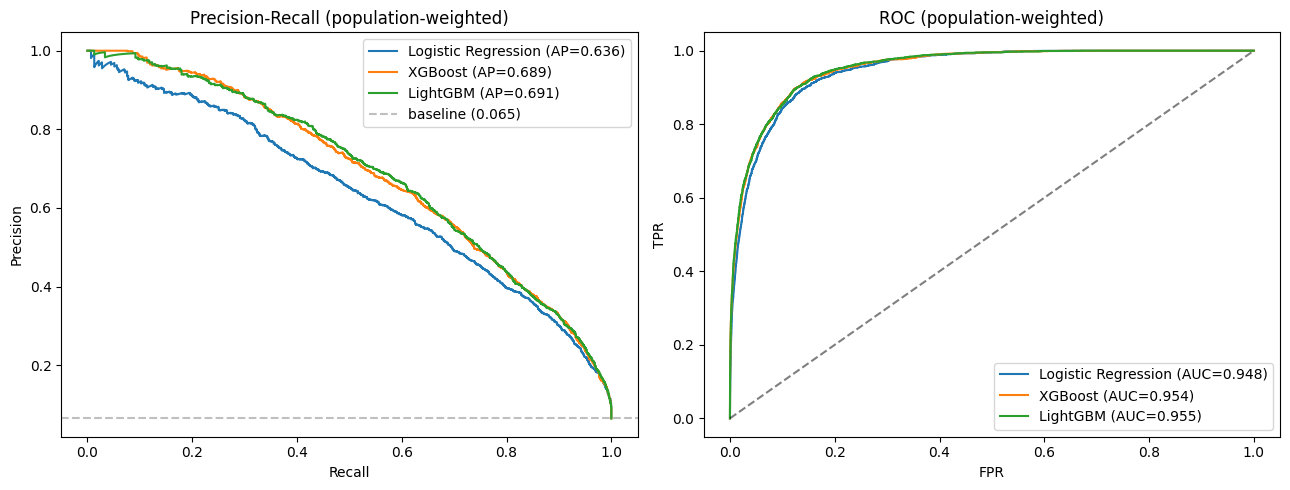

In [28]:
# PR and ROC curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (_, proba) in results.items():
    prec, rec, _ = precision_recall_curve(y_test, proba, sample_weight=w_test)
    fpr, tpr, _  = roc_curve(y_test, proba, sample_weight=w_test)
    ap   = average_precision_score(y_test, proba, sample_weight=w_test)
    auc  = roc_auc_score(y_test, proba, sample_weight=w_test)
    axes[0].plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    axes[1].plot(fpr, tpr,  label=f"{name} (AUC={auc:.3f})")

base_rate = (w_test * y_test).sum() / w_test.sum()
axes[0].axhline(base_rate, ls="--", color="gray", alpha=0.5, label=f"baseline ({base_rate:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall (population-weighted)")
axes[0].legend()

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC (population-weighted)")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

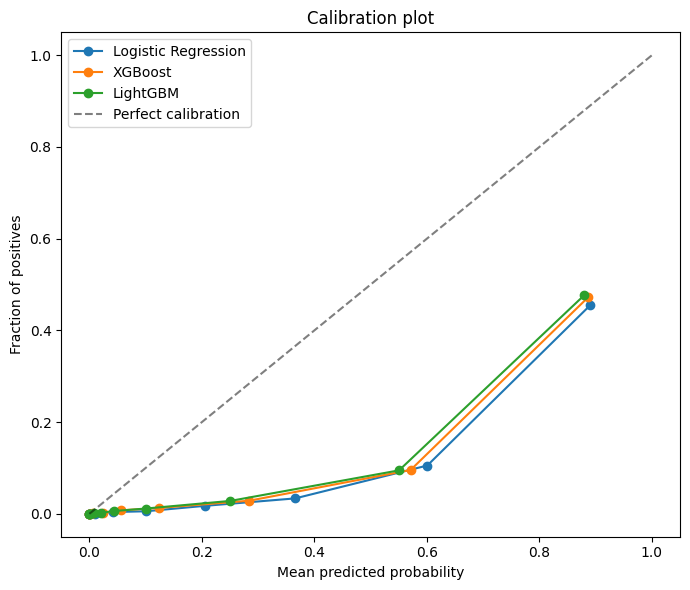

In [29]:
# Calibration plot
fig, ax = plt.subplots(figsize=(7, 6))
for name, (_, proba) in results.items():
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration plot")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "calibration.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Lift Table
def lift_table(y_true, proba, weight, n_bins=10):
    d = pd.DataFrame({"y": y_true.values, "proba": proba, "w": weight.values})
    d["decile"] = pd.qcut(
        d["proba"].rank(method="first"), n_bins,
        labels=[f"D{n_bins-i}" for i in range(n_bins)]
    )
    g = d.groupby("decile", observed=True).agg(
        n=("y", "size"),
        positives=("y", "sum"),
        pop_weight=("w", "sum"),
        weighted_positives=("y", lambda s: (s * d.loc[s.index, "w"]).sum()),
    ).sort_index(ascending=False)

    base_w = (d["w"] * d["y"]).sum() / d["w"].sum()
    g["weighted_pos_rate"] = g["weighted_positives"] / g["pop_weight"]
    g["lift"]              = g["weighted_pos_rate"] / base_w
    g["cum_captured"]      = g["weighted_positives"].cumsum() / g["weighted_positives"].sum()
    return g.round(4)

lift = lift_table(y_test, winner_proba, w_test)
print(lift)
lift.to_csv(REPORTS_DIR / "lift_table.csv")

           n  positives  pop_weight  weighted_positives  weighted_pos_rate    lift  cum_captured
decile                                                                                          
D1      3991       1902  7096414.73          3425449.30             0.4827  7.4757        0.7640
D2      3990        378  7000624.22           715256.48             0.1022  1.5823        0.9235
D3      3991        112  6922893.94           199600.97             0.0288  0.4465        0.9681
D4      3990         46  6988487.30            81894.28             0.0117  0.1815        0.9863
D5      3990         24  6987418.92            39321.95             0.0056  0.0872        0.9951
D6      3991          8  7055118.43            12382.25             0.0018  0.0272        0.9979
D7      3990          6  7221349.88             9575.33             0.0013  0.0205        1.0000
D8      3991          0  6866349.63                0.00             0.0000  0.0000        1.0000
D9      3990          0  67309

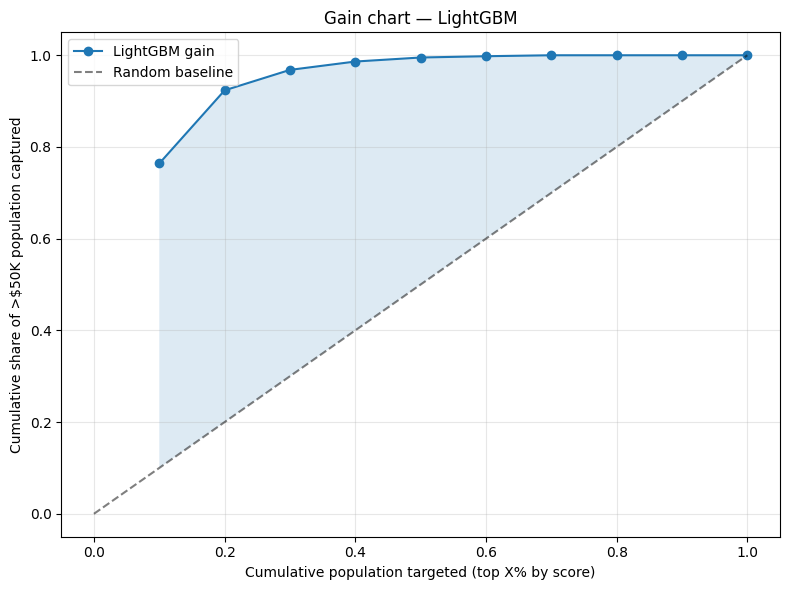

In [ ]:
# Gain chart
cum_pop = np.arange(1, 11) / 10
cum_cap = lift["cum_captured"].values

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(cum_pop, cum_cap, marker="o", label=f"{winner_name} gain")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random baseline")
ax.fill_between(cum_pop, cum_pop, cum_cap, alpha=0.15)
ax.set_xlabel("Cumulative population targeted (top X% by score)")
ax.set_ylabel("Cumulative share of >$50K population captured")
ax.set_title(f"Gain chart — {winner_name}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "gain_chart.png", dpi=150, bbox_inches="tight")
plt.show()

c:\Users\TROY\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


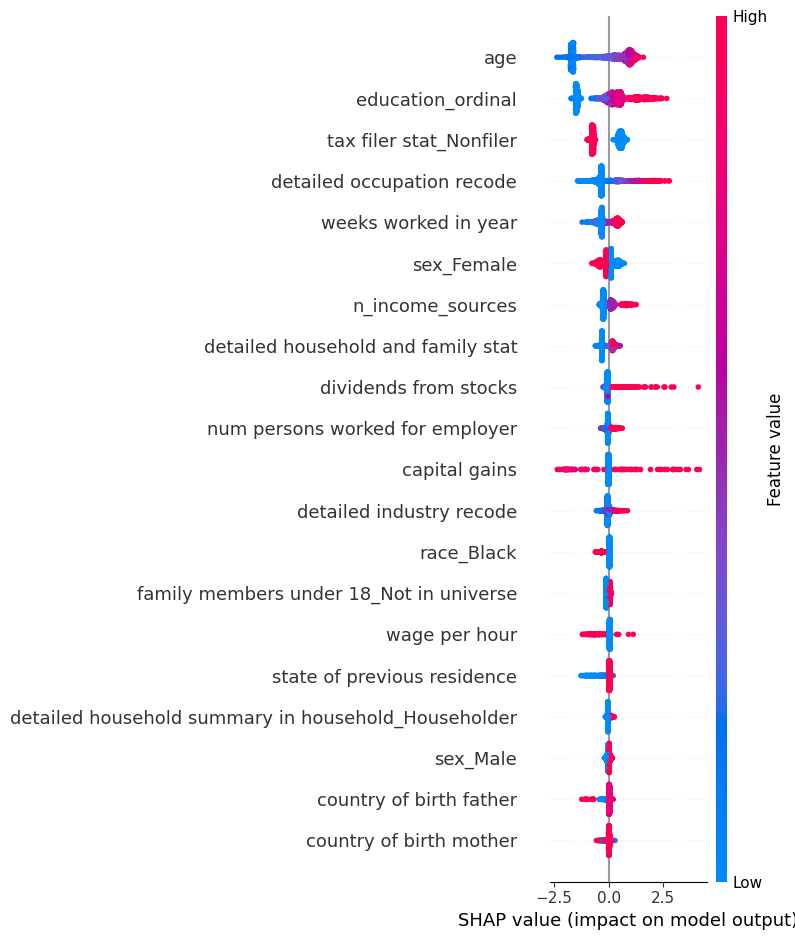

In [ ]:
# SHAP values for feature importance analysis
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=SEED)
explainer = shap.TreeExplainer(winner_model)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
prec, rec, thr = precision_recall_curve(y_test, winner_proba, sample_weight=w_test)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1[:-1])
threshold_f1 = thr[best_idx]
print(f"F1-optimal threshold:  {threshold_f1:.4f}")
print(f"  precision = {prec[best_idx]:.3f}, recall = {rec[best_idx]:.3f}, F1 = {f1[best_idx]:.3f}")

top20_threshold = np.quantile(winner_proba, 0.80)
above = winner_proba >= top20_threshold
prec_20 = ((y_test[above] * w_test[above]).sum() / w_test[above].sum())
rec_20  = ((y_test[above] * w_test[above]).sum() / (y_test * w_test).sum())
print(f"\nTop-20% targeting threshold: {top20_threshold:.4f}")
print(f"  precision in targeted group (population-weighted): {prec_20:.3f}")
print(f"  recall (population-weighted):                       {rec_20:.3f}")

F1-optimal threshold:  0.8531
  precision = 0.637, recall = 0.632, F1 = 0.634

Top-20% targeting threshold: 0.3854
  precision in targeted group (population-weighted): 0.294
  recall (population-weighted):                       0.924


In [34]:
joblib.dump(xgb_clf, DATA_DIR / "xgb_model.joblib")
joblib.dump(lgb_clf, DATA_DIR / "lgb_model.joblib")
joblib.dump(lr,      DATA_DIR / "lr_model.joblib")

scored = X_test.copy()
scored["y_true"]       = y_test.values
scored["weight"]       = w_test.values
scored["lr_score"]     = lr_proba
scored["xgb_score"]    = xgb_proba
scored["lgb_score"]    = lgb_proba
scored["winner_score"] = winner_proba
scored.to_parquet(DATA_DIR / "test_scored.parquet", index=False)
print(f"Models and scored test saved. Winning model: {winner_name}")

Models and scored test saved. Winning model: LightGBM
